# 데이터 불러오기

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [147]:
dataset = pd.read_csv("Google_Stock.csv")
dataset.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,2.490664,2.591785,2.390042,2.499133,2.499133,897427216
1,2004-08-20,2.515820,2.716817,2.503118,2.697639,2.697639,458857488
2,2004-08-23,2.758411,2.826406,2.716070,2.724787,2.724787,366857939
3,2004-08-24,2.770615,2.779581,2.579581,2.611960,2.611960,306396159
4,2004-08-25,2.614201,2.689918,2.587302,2.640104,2.640104,184645512


In [148]:
x = dataset.index.to_frame()
y = dataset[["Close"]]

x.head(), len(x), y.head(), len(y)

(   0
 0  0
 1  1
 2  2
 3  3
 4  4,
 4858,
       Close
 0  2.499133
 1  2.697639
 2  2.724787
 3  2.611960
 4  2.640104,
 4858)

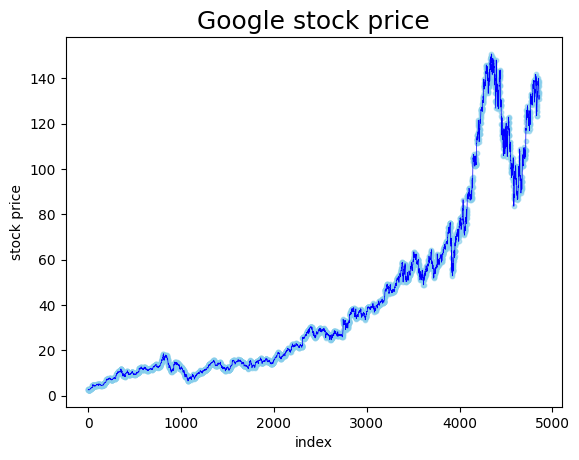

In [149]:
plt.plot(x, y,
                  color="blue",
                  linewidth=0.5)
plt.scatter(x, y,
                  color="skyblue",
                  marker="o",
                  alpha=0.6,
                  s=10)
plt.xlabel("index")
plt.ylabel("stock price")
plt.title("Google stock price", fontsize=18)
plt.show()

## Train test Split

In [150]:
from sklearn.model_selection import train_test_split

In [151]:
x_train, x_test, y_train, y_test = train_test_split(x, y, # 넣을 데이터 지정
                                                                           test_size=0.2, # train : test = 8 : 2
                                                                           random_state=2222,
                                                                           shuffle=True)

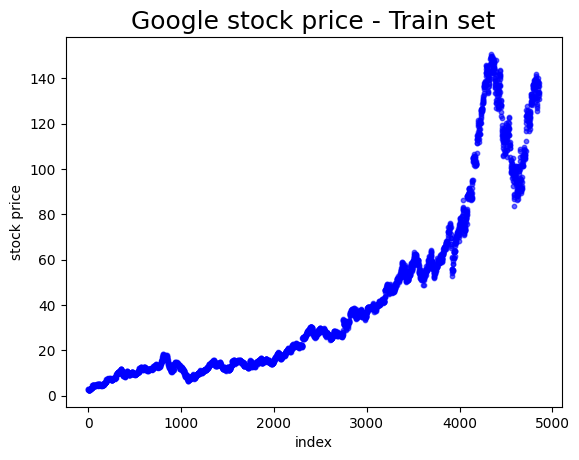

In [152]:
plt.scatter(x_train, y_train,
                  color="blue",
                  marker="o",
                  alpha=0.6,
                  s=10)
plt.xlabel("index")
plt.ylabel("stock price")
plt.title("Google stock price - Train set", fontsize=18)
plt.show()

# Simple Linear Regression (단순선형회귀)

In [153]:
from sklearn.linear_model import LinearRegression

In [154]:
SLR = LinearRegression()

SLR.fit(x_train,y_train)
SLR

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


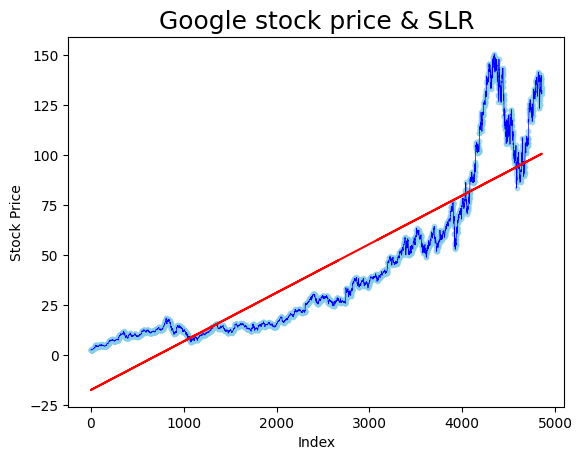

In [155]:
plt.scatter(x, y,
                  color="skyblue",
                  marker="o",
                  alpha=0.6,
                  s=10)
plt.plot(x, y,
                  color="blue",
                  linewidth=0.5)
plt.plot(x_train,SLR.predict(x_train),
             color="red")
plt.title("Google stock price & SLR", fontsize=18)
plt.xlabel("Index")
plt.ylabel("Stock Price")
plt.show()

In [156]:
f"Simple Linear Regression (단순선형회귀) Score : {100 * round(SLR.score(x_test,y_test),5)}%"

'Simple Linear Regression (단순선형회귀) Score : 77.046%'

# Stochastic Gradient Descent (확률적 경사하강법)

In [157]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

In [158]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_scaled = scaler.transform(x)

In [159]:
SGD = SGDRegressor(eta0=0.001)
SGD.fit(x_train_scaled, y_train)

c:\Users\SAMSUNG\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


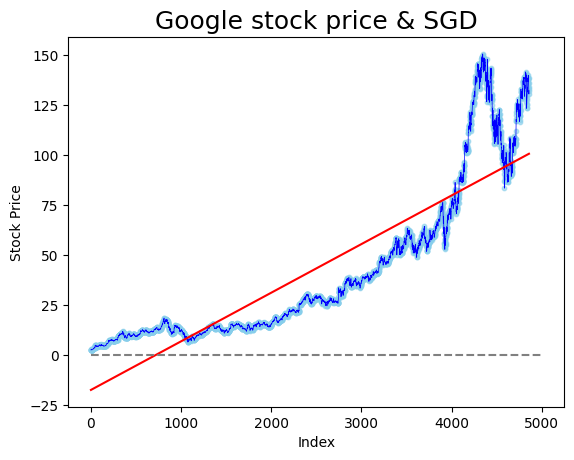

In [160]:
plt.scatter(x, y,
                  color="skyblue",
                  marker="o",
                  alpha=0.6,
                  s=10)
plt.plot(x, y,
                  color="blue",
                  linewidth=0.5)
plt.plot(x,SGD.predict(x_scaled),
             color="red")
plt.plot([0,5000],[0,0],
             color="grey",
             linestyle="--")
plt.title("Google stock price & SGD", fontsize=18)
plt.xlabel("Index")
plt.ylabel("Stock Price")
plt.show()

In [161]:
f"Linear Regression - Stochatic Gradient Descent (선형 회귀 - 확률적 경사하강법) Score : {100 * round(SLR.score(x_test,y_test),5)}%"

'Linear Regression - Stochatic Gradient Descent (선형 회귀 - 확률적 경사하강법) Score : 77.046%'

# Polynomial Regression (다항 회귀)

In [162]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [163]:
Poly_Features = PolynomialFeatures(degree=4) # 4차까지 있는 Polynomial Features 생성

x_train_poly = Poly_Features.fit_transform(x_train)
x_train_poly    

array([[1.00000000e+00, 3.08400000e+03, 9.51105600e+06, 2.93320967e+10,
        9.04601862e+13],
       [1.00000000e+00, 3.22400000e+03, 1.03941760e+07, 3.35108234e+10,
        1.08038895e+14],
       [1.00000000e+00, 3.05500000e+03, 9.33302500e+06, 2.85123914e+10,
        8.71053557e+13],
       ...,
       [1.00000000e+00, 1.15800000e+03, 1.34096400e+06, 1.55283631e+09,
        1.79818445e+12],
       [1.00000000e+00, 1.45000000e+02, 2.10250000e+04, 3.04862500e+06,
        4.42050625e+08],
       [1.00000000e+00, 2.65700000e+03, 7.05964900e+06, 1.87574874e+10,
        4.98386440e+13]], shape=(3886, 5))

In [164]:
scaler = StandardScaler()
x_train_poly_scaled = scaler.fit_transform(x_train_poly)
x_train_poly_scaled

array([[ 0.        ,  0.44484529,  0.20991587, -0.00174296, -0.16093343],
       [ 0.        ,  0.5442228 ,  0.33449772,  0.12565104, -0.04382989],
       [ 0.        ,  0.42425995,  0.18480101, -0.02673276, -0.1832822 ],
       ...,
       [ 0.        , -0.9223052 , -0.94264008, -0.84863041, -0.75157037],
       [ 0.        , -1.64137241, -1.12884405, -0.89587774, -0.76354633],
       [ 0.        ,  0.14174391, -0.13590444, -0.32412389, -0.43154071]],
      shape=(3886, 5))

In [165]:
x_poly = Poly_Features.transform(x)
x_poly_scaled = scaler.transform(x_poly)

In [166]:
POLY = LinearRegression()

POLY.fit(x_train_poly_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


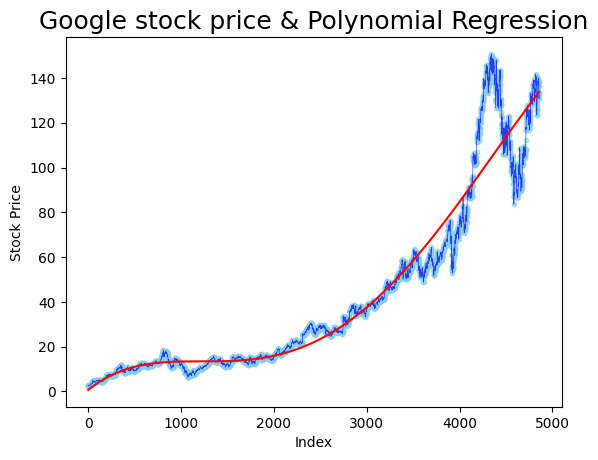

In [167]:
plt.scatter(x, y,
                  color="skyblue",
                  marker="o",
                  alpha=0.6,
                  s=10)
plt.plot(x, y,
                  color="blue",
                  linewidth=0.5,
                  alpha=0.7)
plt.plot(x,POLY.predict(x_poly_scaled),
             color="red")
plt.title("Google stock price & Polynomial Regression", fontsize=18)
plt.xlabel("Index")
plt.ylabel("Stock Price")
plt.show()

In [168]:
x_test_poly = Poly_Features.transform(x_test)
x_test_poly_scaled = scaler.transform(x_test_poly)

In [169]:
f"Polynomial Regression (다항 회귀) score : {100 * round(POLY.score(x_test_poly_scaled,y_test), 5)}%"

'Polynomial Regression (다항 회귀) score : 93.754%'

# 규제 회귀 (과적합 방지용)

## Lasso Regression

**비용 함수에 L2 term(가중치에 제곱을 한 형태)을 사용하여 weight에 규제를 한다.**

In [170]:
from sklearn.linear_model import Lasso

In [171]:
LASSO = Lasso(alpha=0.01) # alpha = 규제하는 정도
LASSO

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [172]:
LASSO.fit(x_train, y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


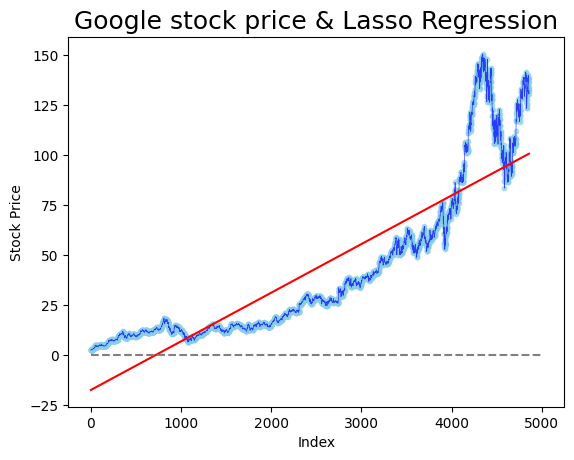

In [182]:
plt.scatter(x, y,
                  color="skyblue",
                  marker="o",
                  alpha=0.6,
                  s=10)
plt.plot(x, y,
                  color="blue",
                  linewidth=0.5,
                  alpha=0.7)
plt.plot(x,LASSO.predict(x),
             color="red")
plt.plot((0,5000),(0,0),
             linestyle="--",
             color="grey")
plt.title("Google stock price & Lasso Regression", fontsize=18)
plt.xlabel("Index")
plt.ylabel("Stock Price")
plt.show()

In [174]:
f"Lasso Regression (라쏘 회귀) score : {100 * round(LASSO.score(x_test,y_test), 5)}%"

'Lasso Regression (라쏘 회귀) score : 77.046%'

## Ridge Regression

**비용 함수에 L2 term(가중치에 제곱을 한 형태)을 사용하여 weight에 규제를 한다.**

In [175]:
from sklearn.linear_model import Ridge

In [176]:
RIDGE = Ridge(alpha=0.001)
RIDGE

,alpha,0.001
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [177]:
RIDGE.fit(x_train, y_train)

,alpha,0.001
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


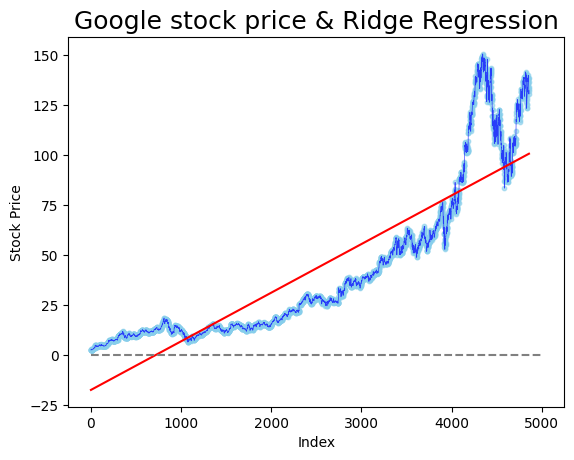

In [178]:
plt.scatter(x, y,
                  color="skyblue",
                  marker="o",
                  alpha=0.6,
                  s=10)
plt.plot(x, y,
                  color="blue",
                  linewidth=0.5,
                  alpha=0.7)
plt.plot(x,RIDGE.predict(x),
             color="red")
plt.plot([0,5000],[0,0],
             linestyle="--",
             color="grey")
plt.title("Google stock price & Ridge Regression", fontsize=18)
plt.xlabel("Index")
plt.ylabel("Stock Price")
plt.show()

In [179]:
f"Ridge Regression (릿지 회귀) score : {100 * round(RIDGE.score(x_test,y_test), 5)}%"

'Ridge Regression (릿지 회귀) score : 77.046%'